# Initialization

## Libraries

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA
from scipy.constants import golden

## Directories

In [2]:
data_dir = Path("data")
Path.mkdir(data_dir, exist_ok=True)

plot_dir = Path("plots")
Path.mkdir(plot_dir, exist_ok=True)

log_dir = Path("logs")
Path.mkdir(log_dir, exist_ok=True)

## Data reading

In [3]:
data_file = "dataset_bo.xlsx"

### Define experimental data

In [4]:
# Define the experimental data
experiment_data = pd.read_excel(data_dir / data_file, sheet_name="Datasheet")

In [5]:
# make the other columns as floats
experiment_data = experiment_data.astype(
    {
        "salt_concentration": float,
        "water_to_cement_ratio": float,
        "antisettling_concentration": float,
        "E_d": float,
        "KPI": float,
    }
)

# get optimization round for later use in saving
opt_round = experiment_data["opt_round"].iloc[-1]

In [6]:
experiment_data.dropna(subset=["E_d"], inplace=True)
experiment_data

,opt_round,salt,salt_concentration,water_to_cement_ratio,antisettling_concentration,kernel,acquisition,obj_func,n_rejected_before_accept,E_d,KPI,Notes
0,0,MgSO4,0.50,1.00,0.00,NaN,NaN,NaN,NaN,39.392651,6.764730,NaN
1,0,CaCl2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,91.053468,2.427368,NaN
2,0,SrBr2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,159.169079,32.224874,NaN
3,0,MgCl2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,88.671748,2.715363,NaN
4,0,CuSO4,0.50,1.00,0.00,NaN,NaN,NaN,NaN,9.658742,61.776688,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
97,4,MgCl2,0.15,1.25,0.00,RBF,EI,KPI,15.0,46.623793,4.038395,NaN
98,4,MgSO4,0.33,0.88,0.01,RBF,PI,KPI,34.0,23.165120,10.785614,NaN
99,4,MgCl2,0.55,1.07,1.07,RBF,LCB_low,KPI,8.0,57.119079,6.645415,NaN
100,4,Zn(NO3)2,0.16,1.24,1.04,RBF,LCB_med,KPI,4.0,41.951700,15.922248,NaN


# Plots

In [7]:
# Define fixed color maps
salt_colors = {
    "Al2(SO4)3": "#9e0142",
    "CaCl2": "#c33033",
    "CuSO4": "#f46d43",
    "K2CO3": "#fdae61",
    "KAl(SO4)2": "#fee08b",
    "LiCl": "#bfbfbf",
    "Mg(NO3)2": "#e6f598",
    "MgCl2": "#abdda4",
    "MgSO4": "#66c2a5",
    "SrBr2": "#388088",
    "Zn(NO3)2": "#5e4fa2",
}

# Remove datapoints with Notes
df_clean = experiment_data[experiment_data["Notes"] != "Penalizzato"]

## Optimization

### Sorted

C:\Users\giulio.barletta\AppData\Local\Temp\ipykernel_33840\1867377674.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


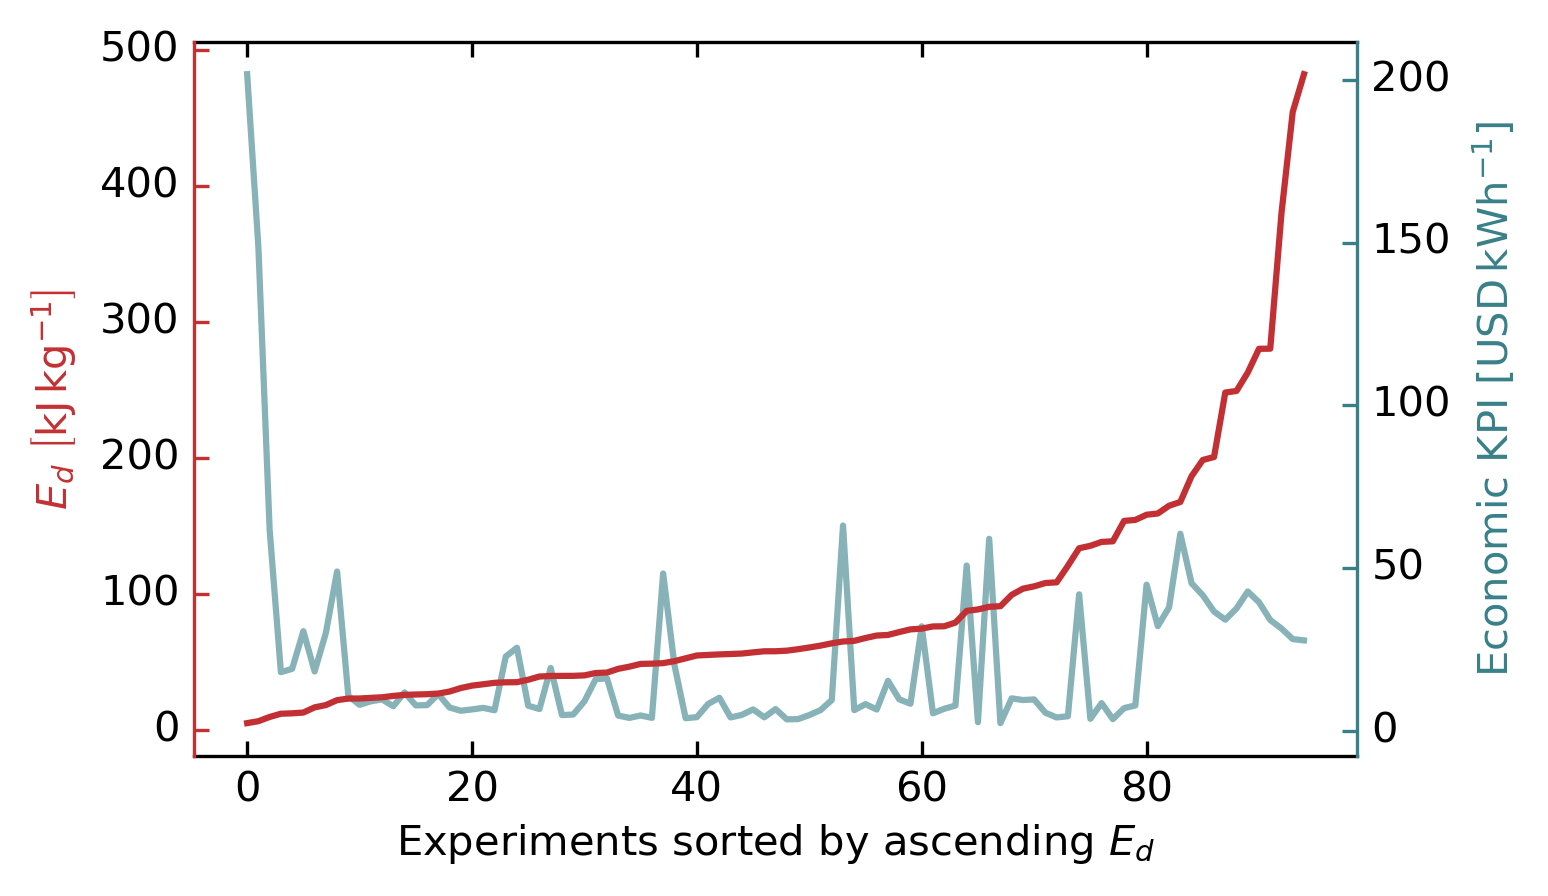

In [8]:
# Create figure
fig = plt.figure(figsize=(5, 5 / golden), dpi=300)

# Sort by E_d
df_sorted_Ed = df_clean.sort_values("E_d").reset_index(drop=True)

# Host axis (left y-axis for E_d)
host = host_subplot(111, axes_class=AA.Axes)

# Create two parasite axis for the right side
par1 = host.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host.plot(
    df_sorted_Ed.index, df_sorted_Ed["E_d"], color="#c33033", label=r"$E_d$", zorder=3
)
(p2,) = par1.plot(
    df_sorted_Ed.index, df_sorted_Ed["KPI"], color="#388088", label="KPI", alpha=0.6
)

# Axis labels
host.set_xlabel(r"Experiments sorted by ascending $E_d$")
host.set_ylabel(r"$E_d \,\, \rm{\left[ kJ \, kg^{-1} \right]}$")
par1.set_ylabel(r"Economic KPI $\rm{\left[ USD \, kWh^{-1} \right]}$")

# Colors match the plots
host.axis["left"].label.set_color(p1.get_color())
host.axis["left"].line.set_color(p1.get_color())
host.axis["left"].major_ticks.set_color(p1.get_color())
par1.axis["right"].label.set_color(p2.get_color())
par1.axis["right"].line.set_color(p2.get_color())
par1.axis["right"].major_ticks.set_color(p2.get_color())

# # Legend
# lines = [p1, p2]
# host.legend(lines, [line.get_label() for line in lines], loc="upper center")

fig.savefig("plots/sorted_ed.pdf", bbox_inches="tight", pad_inches=0.05)
fig.savefig("plots/sorted_ed.svg", bbox_inches="tight", pad_inches=0.05)
fig.show()

C:\Users\giulio.barletta\AppData\Local\Temp\ipykernel_33840\1190199294.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


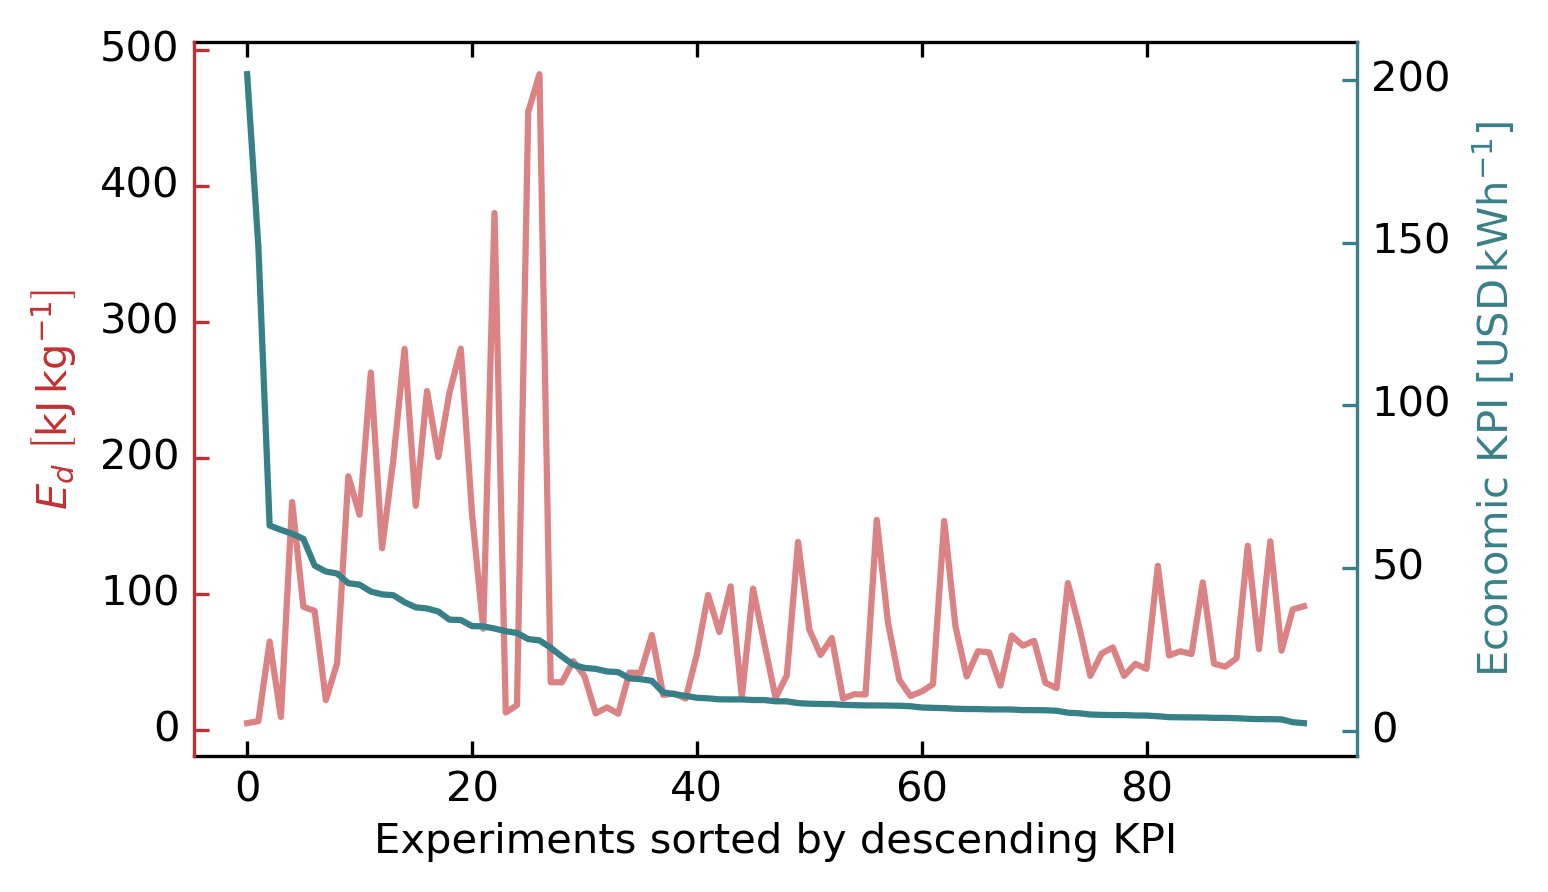

In [ ]:
# Create figure
fig = plt.figure(figsize=(5, 5 / golden), dpi=300)

# Sort by KPI
df_sorted_KPI = df_clean.sort_values("KPI", ascending=False).reset_index(drop=True)

# Host axis (left y-axis for E_d)
host2 = host_subplot(111, axes_class=AA.Axes)

# Create two parasite axes for the right side
par1 = host2.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host2.plot(
    df_sorted_KPI.index,
    df_sorted_KPI["E_d"],
    color="#c33033",
    label=r"$E_d$",
    alpha=0.6,
)
(p2,) = par1.plot(
    df_sorted_KPI.index, df_sorted_KPI["KPI"], color="#388088", label="KPI", zorder=3
)

# Axis labels
host2.set_xlabel(r"Experiments sorted by descending KPI")
host2.set_ylabel(r"$E_d \,\, \rm{\left[ kJ \, kg^{-1} \right]}$")
par1.set_ylabel(r"Economic KPI $\rm{\left[ USD \, kWh^{-1} \right]}$")

# Colors match the plots
host2.axis["left"].label.set_color(p1.get_color())
host2.axis["left"].line.set_color(p1.get_color())
host2.axis["left"].major_ticks.set_color(p1.get_color())
par1.axis["right"].label.set_color(p2.get_color())
par1.axis["right"].line.set_color(p2.get_color())
par1.axis["right"].major_ticks.set_color(p2.get_color())

# # Legend
# lines = [p1, p2]
# host2.legend(lines, [line.get_label() for line in lines], loc="upper center")

fig.savefig("plots/sorted_kpi.pdf", bbox_inches="tight", pad_inches=0.05)
fig.savefig("plots/sorted_kpi.svg", bbox_inches="tight", pad_inches=0.05)
fig.show()

### Chronological

C:\Users\giulio.barletta\AppData\Local\Temp\ipykernel_33840\4260573392.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


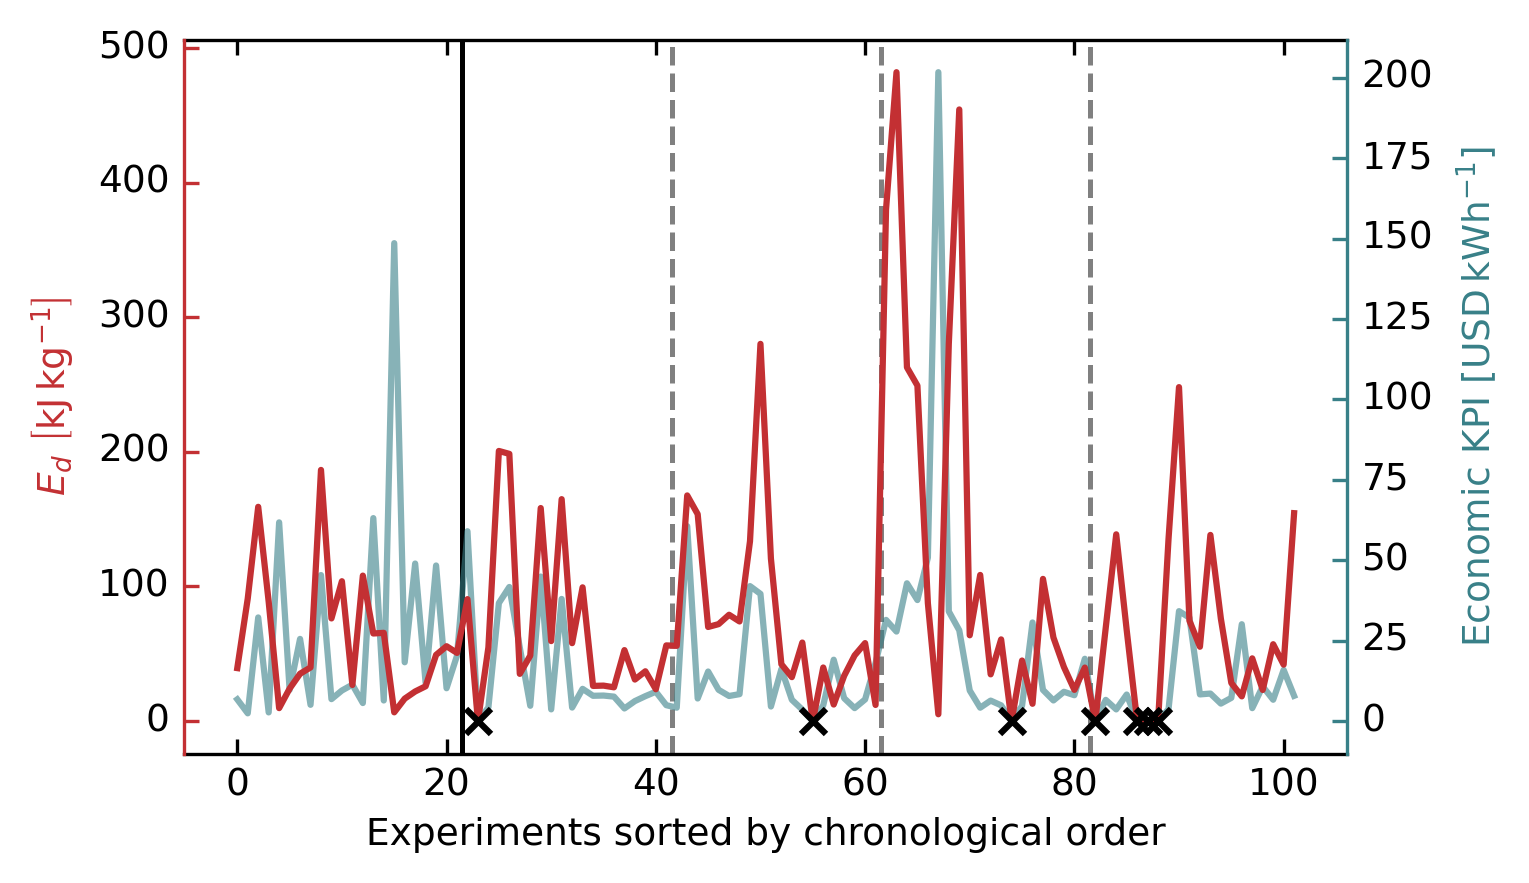

In [46]:
df_unsorted = experiment_data
df_unsorted.loc[df_unsorted["Notes"] == "Penalizzato", "E_d"] = 0
df_unsorted.loc[df_unsorted["Notes"] == "Penalizzato", "KPI"] = 0

penalized_pts = df_unsorted.loc[df_unsorted["Notes"] == "Penalizzato"]

# Create figure
fig = plt.figure(figsize=(5, 5 / golden), dpi=300)

# Host axis (left y-axis for E_d)
host = host_subplot(111, axes_class=AA.Axes)

# Create parasite axis for the right side
par1 = host.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host.plot(
    df_unsorted.index, df_unsorted["E_d"], color="#c33033", label=r"$E_d$", zorder=2
)

host.scatter(penalized_pts.index, penalized_pts["E_d"], color="k", marker="x", zorder=3)

(p2,) = par1.plot(
    df_unsorted.index,
    df_unsorted["KPI"],
    color="#388088",
    label="KPI",
    alpha=0.6,
    zorder=1,
)

# vertical lines on the shared x-axis (host)
host.axvline(
    x=21.5, color="black", linestyle="-", linewidth=1.2, zorder=0
)  # solid black
for xpos in [41.5, 61.5, 81.5]:
    host.axvline(
        x=xpos, color="gray", linestyle="--", linewidth=1.2, zorder=0
    )  # dashed gray

# Axis labels
host.set_xlabel("Experiments sorted by chronological order")
host.set_ylabel(r"$E_d \,\, \rm{\left[ kJ \, kg^{-1} \right]}$")
par1.set_ylabel(r"Economic KPI $\rm{\left[ USD \, kWh^{-1} \right]}$")

# Colors match the plots
host.axis["left"].label.set_color(p1.get_color())
host.axis["left"].line.set_color(p1.get_color())
host.axis["left"].major_ticks.set_color(p1.get_color())
par1.axis["right"].label.set_color(p2.get_color())
par1.axis["right"].line.set_color(p2.get_color())
par1.axis["right"].major_ticks.set_color(p2.get_color())

# # Legend
# lines = [p1, p2]
# host.legend(lines, [line.get_label() for line in lines], loc="best")

fig.savefig("plots/chronological.pdf", bbox_inches="tight", pad_inches=0.05)
fig.savefig("plots/chronological.svg", bbox_inches="tight", pad_inches=0.05)

fig.show()

## Pareto front

In [11]:
def is_pareto_efficient(costs, return_mask=True):
    """
    Find the Pareto-efficient points.
    Args:
        costs: (n_points, n_costs) array. Lower values are better.
        return_mask: If True, returns a boolean mask. Otherwise, indices.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Any point that is strictly worse in all objectives is dominated
            is_efficient[is_efficient] = np.any(
                costs[is_efficient] < c, axis=1
            ) | np.all(costs[is_efficient] == c, axis=1)
    return is_efficient if return_mask else np.where(is_efficient)[0]

In [12]:
f1 = df_clean["E_d"]  # Objective 1 (to MAXIMIZE)
f2 = df_clean["KPI"]  # Objective 2 (to MINIMIZE)

# Define optimization directions (+1 for minimize, -1 for maximize)
# Here: maximize f1, minimize f2
directions = np.array([-1, 1])

# Convert all objectives to a "cost" form (lower is better)
costs = np.column_stack((f1, f2)) * directions

# === Compute Pareto front ===
mask = is_pareto_efficient(costs)
pareto_points = np.column_stack((f1, f2))[mask]
dominated_points = np.column_stack((f1, f2))[~mask]

# === Sort front for prettier plotting ===
pareto_points = pareto_points[np.argsort(pareto_points[:, 0])]

In [13]:
df_clean[mask]

,opt_round,salt,salt_concentration,water_to_cement_ratio,antisettling_concentration,kernel,acquisition,obj_func,n_rejected_before_accept,E_d,KPI,Notes
1,0,CaCl2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,91.053468,2.427368,NaN
44,2,Zn(NO3)2,0.51,1.50,0.00,Matern,LCB_low,E_d,0.0,153.737907,7.035855,NaN
63,3,LiCl,0.89,1.20,0.48,Matern,PI,E_d,28.0,481.969786,27.838036,NaN
84,4,CaCl2,0.90,1.43,3.00,Matern,LCB_low,E_d,37.0,138.729082,3.653351,NaN
101,4,Zn(NO3)2,0.65,1.40,0.00,RBF,LCB_high,KPI,12.0,154.456128,7.868015,NaN


C:\Users\giulio.barletta\AppData\Local\Temp\ipykernel_33840\1763802330.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


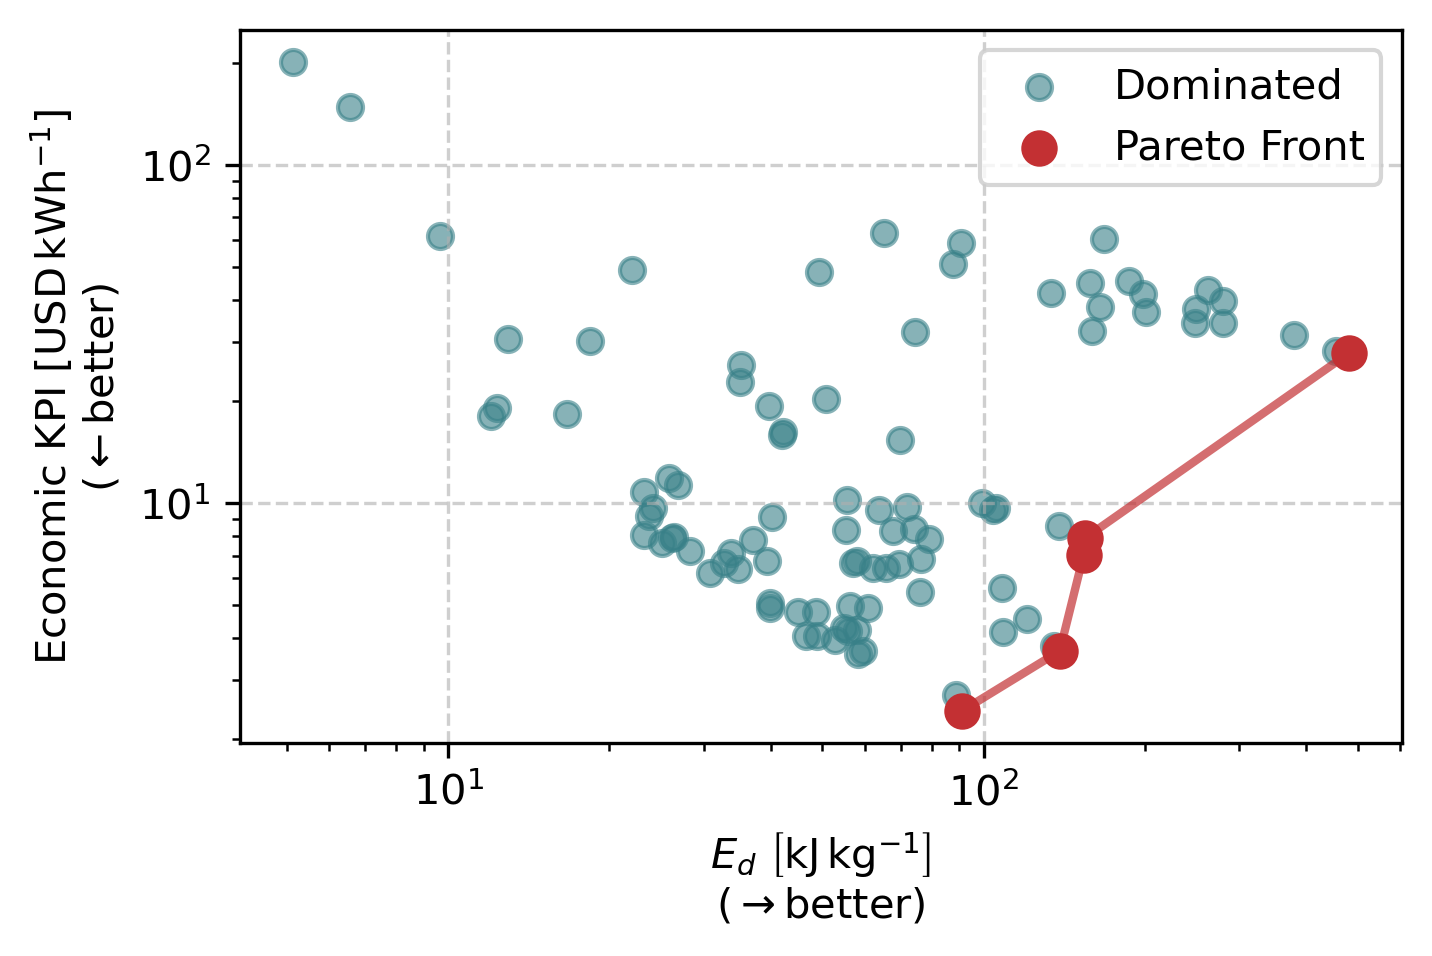

In [14]:
# === Plot ===
fig, ax = plt.subplots(figsize=(5, 5 / golden), dpi=300)
ax.scatter(
    dominated_points[:, 0],
    dominated_points[:, 1],
    color="#388088",
    alpha=0.6,
    label="Dominated",
)
ax.scatter(
    pareto_points[:, 0],
    pareto_points[:, 1],
    color="#c33033",
    s=60,
    label="Pareto Front",
)
ax.loglog(pareto_points[:, 0], pareto_points[:, 1], color="#c33033", lw=2, alpha=0.7)

ax.set_xlabel(
    r"$E_d \,\, \rm{\left[ kJ \, kg^{-1} \right]}$" "\n" r"$(\rightarrow \rm{better})$"
)
ax.set_ylabel(
    r"Economic KPI $\rm{\left[ USD \, kWh^{-1} \right]}$"
    "\n"
    r"$(\leftarrow \rm{better})$"
)
# plt.title("Pareto Front with Mixed Objectives", fontsize=14)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
# plt.tight_layout()
fig.savefig("plots/pareto.pdf", bbox_inches="tight", pad_inches=0.05)
fig.savefig("plots/pareto.svg", bbox_inches="tight", pad_inches=0.05)

fig.show()

# Isotherms

## Data reading

In [3]:
data_file = "dataset_plots.xlsx"

In [5]:
plot_data = pd.read_excel(data_dir / data_file, sheet_name="final_plots")

In [6]:
plot_data

,Params,RH [%],PC,CaCl_1,CaCl_12,ZnN_5,ZnN_15,LiCl_10,p_20,p_tr_40 LiCl_10,p_tr_90 LiCl_10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,RH [%],dm [g/g],dm [g/g],dm [g/g],dm [g/g],dm [g/g],dm [g/g],NaN,NaN,NaN
2,NaN,0,0,0,0,0,0,0,0.00000,0,0.000000
3,NaN,5,NaN,NaN,0.012082,0.008924,0.004207,0.048975,1.16965,4.471031,62.514310
4,NaN,10,0.017495,0.046422,0.029011,0.026564,0.015014,0.094605,2.33930,8.554838,109.391494
5,NaN,15,NaN,NaN,0.06708,0.074026,0.073962,0.249582,3.50895,12.504219,151.751100
6,NaN,20,0.027877,0.069146,0.100263,0.098078,0.093521,0.306399,4.67860,16.368762,191.420156
7,NaN,25,NaN,NaN,0.132297,0.120035,0.132894,0.369937,5.84825,20.171421,229.201532
8,NaN,30,0.037248,0.098396,0.158132,0.140746,0.156564,0.433475,7.01790,23.92548,265.543673
9,NaN,35,NaN,NaN,0.224701,0.161893,0.177985,0.509171,8.18755,27.639599,300.731023


In [7]:
def DA_fit(salt: str, T: int):
    R = 8.314
    p0_20 = 23.393
    p0_40 = 73.849
    p0_90 = 701.82
    T_abs = T + 273.15
    if T == 20:
        p_array = np.array(plot_data["p_20"][2:13])
        p = np.linspace(p_array[0], p_array[-1], 100)
        p0 = p0_20
    elif T == 40 and salt == "LiCl_10":
        p_array = np.array(plot_data["p_tr_40 LiCl_10"][2:13])
        p = np.linspace(p_array[0], p_array[-1], 100)
        p0 = p0_40
    elif T == 90 and salt == "LiCl_10":
        p_array = np.array(plot_data["p_tr_90 LiCl_10"][2:13])
        p = np.linspace(p_array[0], p_array[-1], 100)
        p0 = p0_90
    else:
        print("Invalid argument.")

    w0 = plot_data[salt][20]
    E = plot_data[salt][21]
    n = plot_data[salt][22]
    A = -R * T_abs * np.log(p / p0)
    # print(A)

    return p, w0 * np.exp(-((A / E) ** n))

C:\Users\giulio.barletta\AppData\Local\Temp\ipykernel_54704\1153879248.py:25: RuntimeWarning: divide by zero encountered in log
  A = - R * T_abs * np.log(p/p0)


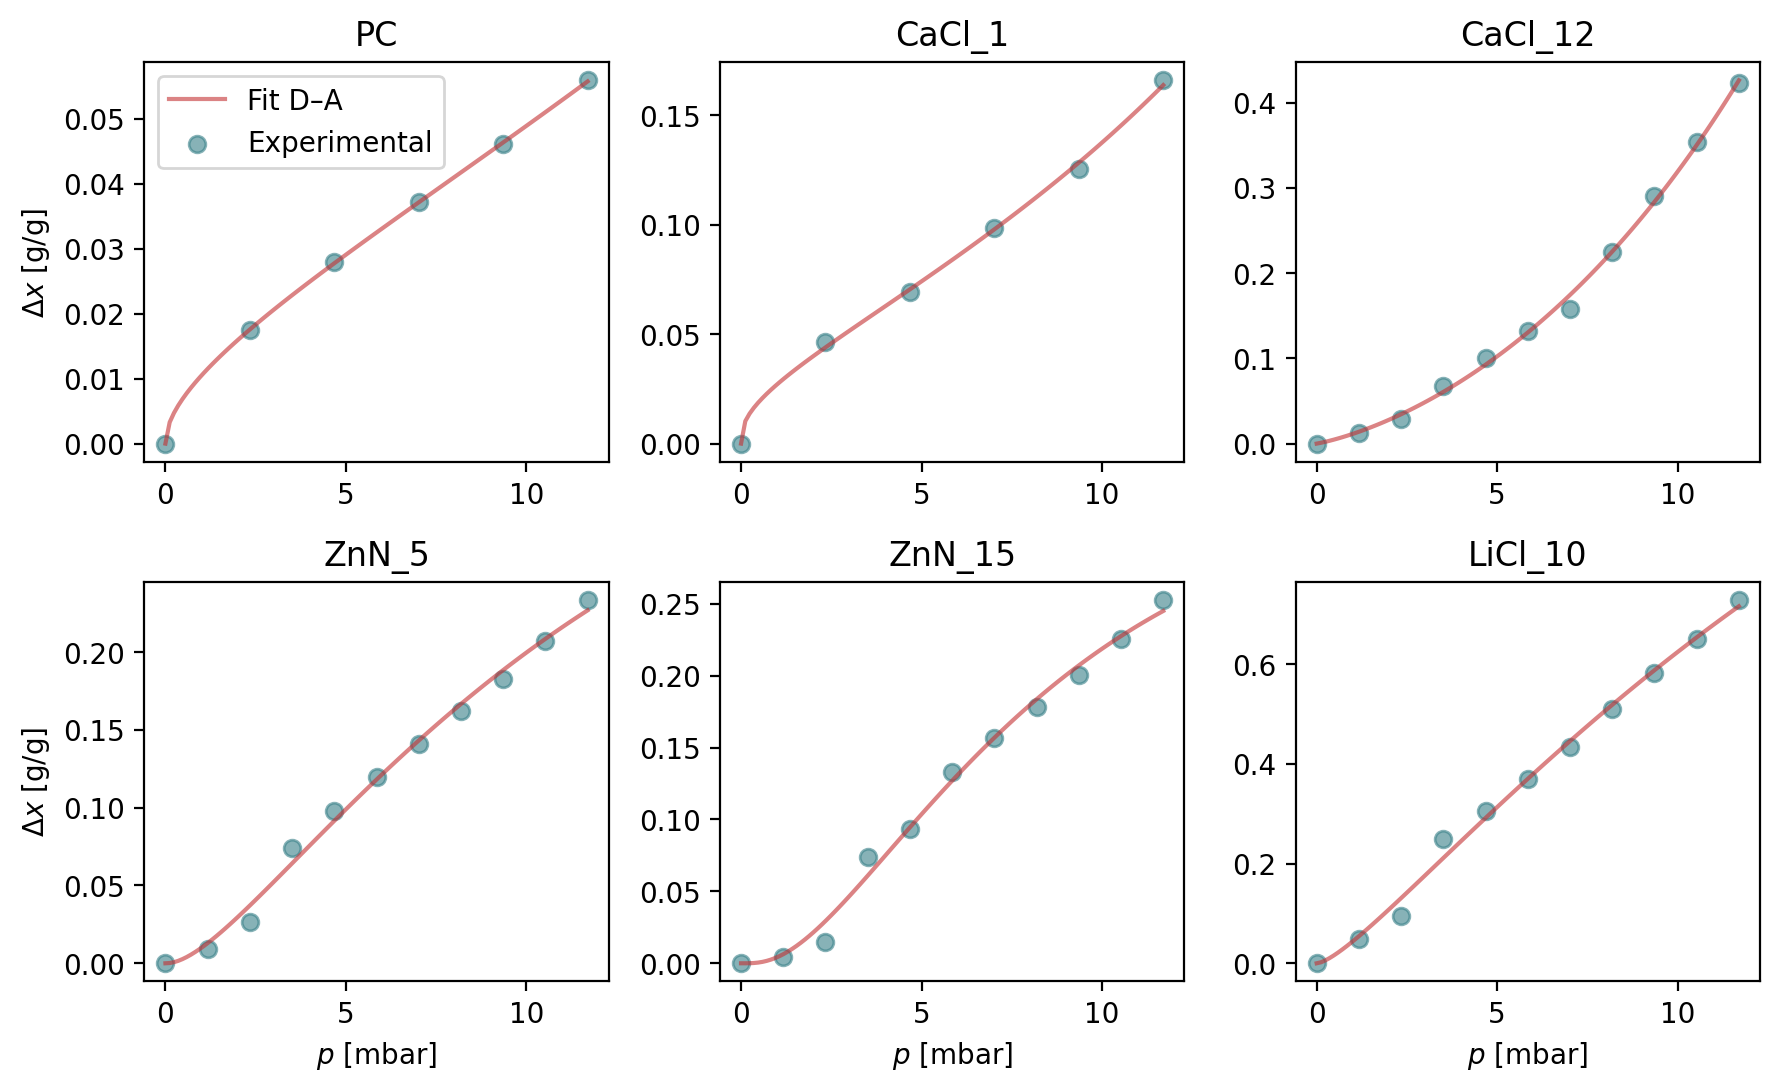

In [8]:
fig = plt.figure(dpi=200, figsize=(9, 9 / golden))
salts = ["PC", "CaCl_1", "CaCl_12", "ZnN_5", "ZnN_15", "LiCl_10"]

i = 1
for salt in salts:
    p = np.array(plot_data["p_20"][2:13])
    dx = np.array(plot_data[salt][2:13])
    p_fit, fit = DA_fit(salt, 20)

    ax = fig.add_subplot(2, 3, i)
    plt.plot(p_fit, fit, color="#c33033", alpha=0.6, label="Fit D–A")
    plt.scatter(p, dx, color="#388088", alpha=0.6, label="Experimental")
    if i > 3:
        ax.set_xlabel(r"$p$ [mbar]")
    if i == 1 or i == 4:
        ax.set_ylabel(r"$\Delta x$ [g/g]")
    ax.set_title(f"{salt}")
    if i == 1:
        plt.legend()
    fig.tight_layout()
    i += 1

fig.savefig("plots/best.pdf", bbox_inches="tight", pad_inches=0.05)
fig.savefig("plots/best.svg", bbox_inches="tight", pad_inches=0.05)

In [9]:
p_fit_20, fit_20 = DA_fit("LiCl_10", 20)
p_fit_40, fit_40 = DA_fit("LiCl_10", 40)
p_fit_90, fit_90 = DA_fit("LiCl_10", 90)

C:\Users\giulio.barletta\AppData\Local\Temp\ipykernel_54704\1153879248.py:25: RuntimeWarning: divide by zero encountered in log
  A = - R * T_abs * np.log(p/p0)


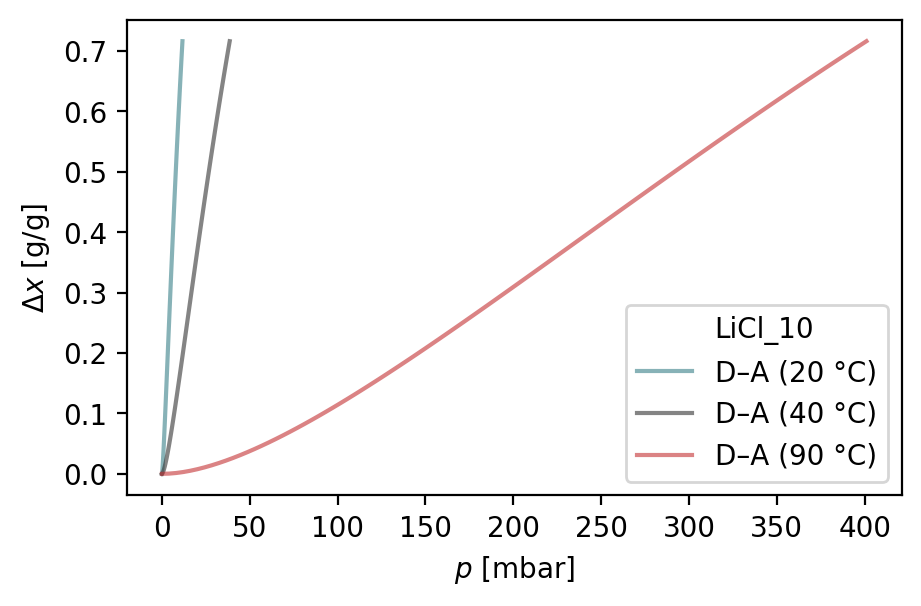

In [10]:
fig = plt.figure(dpi=200, figsize=(5, 5 / golden))
# Text-only legend entry
text_only = Line2D([], [], linestyle="none", label="LiCl_10")
plt.plot(p_fit_20, fit_20, color="#388088", alpha=0.6, label="D–A (20 °C)")
plt.plot(p_fit_40, fit_40, color="#333333", alpha=0.6, label="D–A (40 °C)")
plt.plot(p_fit_90, fit_90, color="#c33033", alpha=0.6, label="D–A (90 °C)")
plt.xlabel(r"$p$ [mbar]")
plt.ylabel(r"$\Delta x$ [g/g]")
plt.legend(handles=[text_only] + plt.gca().get_legend_handles_labels()[0])

fig.savefig("plots/shift.pdf", bbox_inches="tight", pad_inches=0.05)
fig.savefig("plots/shift.svg", bbox_inches="tight", pad_inches=0.05)

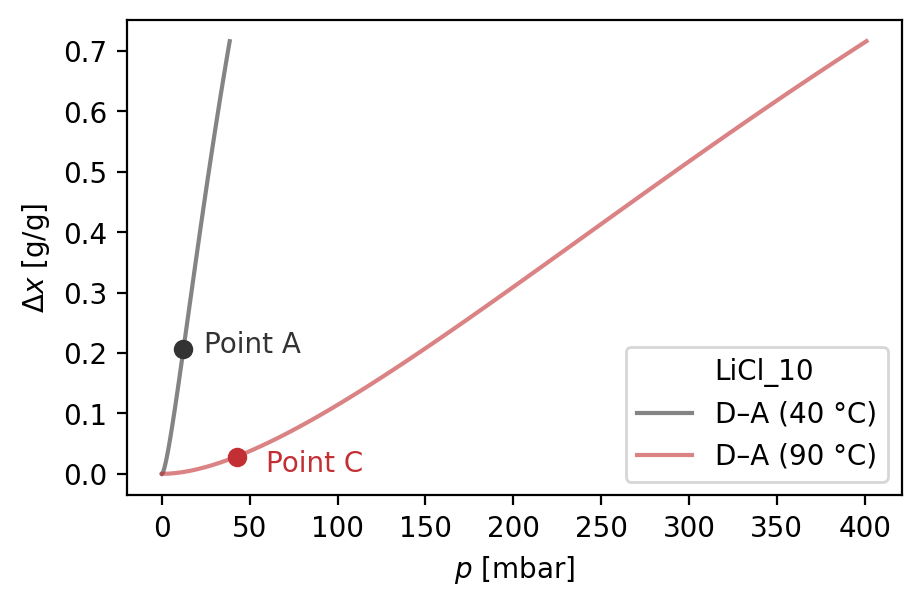

In [11]:
pA = 12.282
pC = 42.47
xC = 0.028
xA = 0.207

fig = plt.figure(dpi=200, figsize=(5, 5 / golden))
plt.plot(p_fit_40, fit_40, color="#333333", alpha=0.6, label="D–A (40 °C)")
plt.scatter(pA, xA, color="#333333")
plt.annotate(
    "Point A", xy=(0.1, 0.3), xycoords="axes fraction", fontsize=10, color="#333333"
)
plt.plot(p_fit_90, fit_90, color="#c33033", alpha=0.6, label="D–A (90 °C)")
plt.scatter(pC, xC, color="#c33033")
plt.annotate(
    "Point C", xy=(0.18, 0.05), xycoords="axes fraction", fontsize=10, color="#c33033"
)
text_only = Line2D([], [], linestyle="none", label="LiCl_10")
plt.xlabel(r"$p$ [mbar]")
plt.ylabel(r"$\Delta x$ [g/g]")
# plt.title(r"Composite LiCl_10")
plt.legend(handles=[text_only] + plt.gca().get_legend_handles_labels()[0])

fig.savefig("plots/points.pdf", bbox_inches="tight", pad_inches=0.05)
fig.savefig("plots/points.svg", bbox_inches="tight", pad_inches=0.05)

# Placeholder plots

In [56]:
# Reproducibility
rng = np.random.default_rng(42)

# Simple, clean defaults
plt.rcParams.update(
    {
        "figure.dpi": 200,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
    }
)

## Optimization

In [57]:
# Schematic campaign settings
n_init = 22  # initial random set (matches your paper)
batch = 20  # BO batch size
n_batches = 4  # how many BO batches to show in the placeholder
n_total = n_init + n_batches * batch

x = np.arange(1, n_total + 1)

# Create schematic signals (no physical meaning)
# Objective 1 (Ed-like): generally increases with some noise
trend_ed = np.linspace(0.2, 0.85, n_total)
ed = trend_ed + 0.12 * rng.normal(size=n_total)
ed = np.clip(ed, 0.02, 0.98)

# Objective 2 (KPI-like): generally decreases with noise
trend_kpi = np.linspace(0.85, 0.25, n_total)
kpi = trend_kpi + 0.10 * rng.normal(size=n_total)
kpi = np.clip(kpi, 0.02, 0.98)

# For the schematic plot, show failed points at zero (purely visual convention)
ed_plot = ed.copy()
kpi_plot = kpi.copy()

C:\Users\giulio.barletta\AppData\Local\Temp\ipykernel_33840\1620047770.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


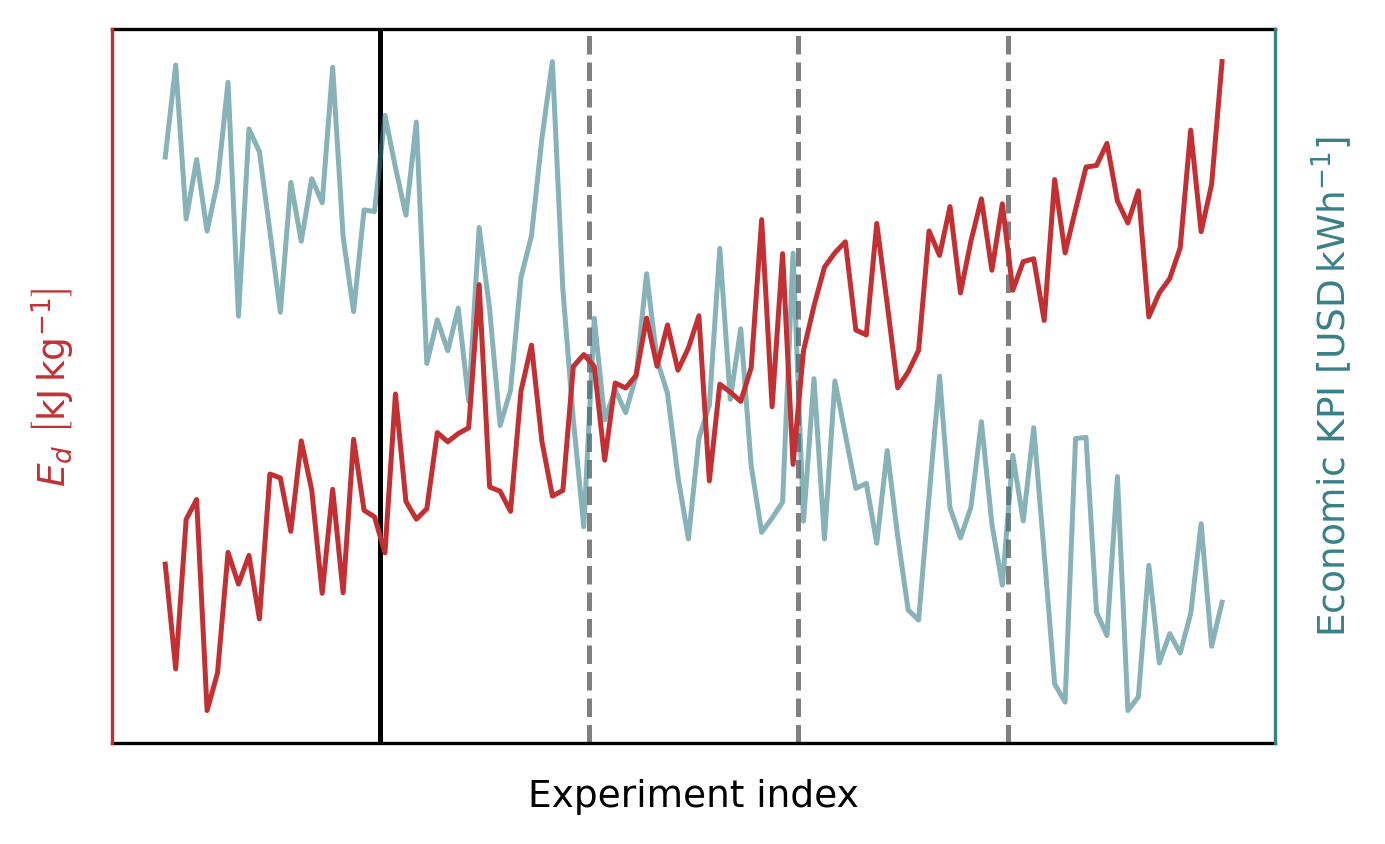

In [58]:
# Create figure
fig = plt.figure(figsize=(5, 5 / golden), dpi=300)

# Host axis (left y-axis for E_d)
host = host_subplot(111, axes_class=AA.Axes)

# Create parasite axis for the right side
par1 = host.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host.plot(x, ed_plot, lw=1.2, label=r"$E_d$", c="#c33033", zorder=2)

(p2,) = par1.plot(
    x, kpi_plot, lw=1.2, label="Economic KPI", c="#388088", alpha=0.6, zorder=1
)

# vertical lines on the shared x-axis (host)
host.axvline(
    x=21.5, color="black", linestyle="-", linewidth=1.2, zorder=0
)  # solid black
for xpos in [41.5, 61.5, 81.5]:
    host.axvline(
        x=xpos, color="gray", linestyle="--", linewidth=1.2, zorder=0
    )  # dashed gray

# Axis labels
host.set_xlabel("Experiment index")
host.set_ylabel(r"$E_d \,\, \rm{\left[ kJ \, kg^{-1} \right]}$")
par1.set_ylabel(r"Economic KPI $\rm{\left[ USD \, kWh^{-1} \right]}$")

# Colors match the plots
host.axis["left"].label.set_color(p1.get_color())
host.axis["left"].line.set_color(p1.get_color())
host.axis["left"].major_ticks.set_color(p1.get_color())
for s in ["left", "right", "bottom", "top"]:
    host.axis[s].major_ticks.set_visible(False)
    host.axis[s].major_ticklabels.set_visible(False)

par1.axis["right"].label.set_color(p2.get_color())
par1.axis["right"].line.set_color(p2.get_color())
par1.axis["right"].major_ticks.set_color(p2.get_color())
for s in ["left", "right", "bottom", "top"]:
    par1.axis[s].major_ticks.set_visible(False)
    par1.axis[s].major_ticklabels.set_visible(False)

fig.savefig("publication/new_data.pdf", bbox_inches="tight", pad_inches=0.05)

fig.show()

## Pareto

In [59]:
n_points = 55

# x = Ed-like (to maximize), y = KPI-like (to minimize)
# Create a cloud with a clear trade-off structure
ed2 = rng.uniform(0.1, 0.95, n_points)
# KPI decreases as Ed increases, with noise
kpi2 = 0.95 - 0.8 * ed2 + 0.12 * rng.normal(size=n_points)
kpi2 = np.clip(kpi2, 0.05, 0.98)

# Define Pareto front: maximize Ed, minimize KPI
# A point is Pareto-optimal if no other point has Ed >= and KPI <= with at least one strict
pareto = np.ones(n_points, dtype=bool)
for i in range(n_points):
    if not pareto[i]:
        continue
    dominated_by_any = np.any(
        (ed2 >= ed2[i]) & (kpi2 <= kpi2[i]) & ((ed2 > ed2[i]) | (kpi2 < kpi2[i]))
    )
    if dominated_by_any:
        pareto[i] = False

# Sort Pareto points by Ed for a nice polyline
pf_idx = np.where(pareto)[0]
pf_idx = pf_idx[np.argsort(ed2[pf_idx])]

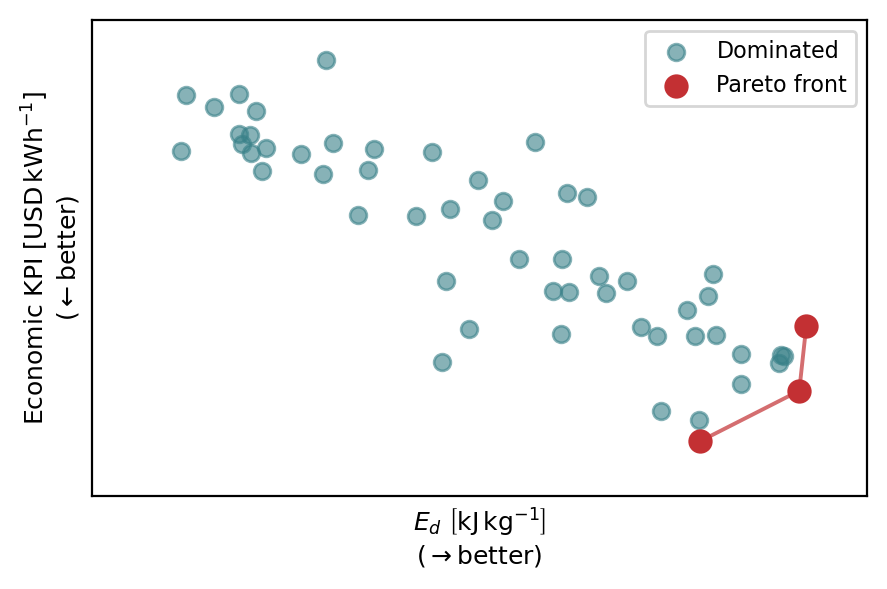

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5 / golden))

ax.scatter(ed2[~pareto], kpi2[~pareto], alpha=0.6, label="Dominated", c="#388088")
ax.scatter(ed2[pareto], kpi2[pareto], s=60, label="Pareto front", c="#c33033")

# Frontier line
ax.plot(ed2[pf_idx], kpi2[pf_idx], lw=1.4, c="#c33033", alpha=0.7)

ax.set_xlabel(
    r"$E_d \,\, \rm{\left[ kJ \, kg^{-1} \right]}$" "\n" r"$(\rightarrow \rm{better})$"
)
ax.set_ylabel(
    r"Economic KPI $\rm{\left[ USD \, kWh^{-1} \right]}$"
    "\n"
    r"$(\leftarrow \rm{better})$"
)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)

ax.axes.get_xaxis().set_ticks([])
ax.axes.get_yaxis().set_ticks([])

ax.legend(loc="upper right", frameon=True)
ax.grid(True, alpha=0.25)

fig.savefig("publication/pareto.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()